## 1. Import Libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import datetime as dt

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer 
from sklearn.metrics import silhouette_score , silhouette_samples, calinski_harabasz_score
from sklearn.mixture import GaussianMixture
import plotly.express as px
import warnings
import joblib
warnings.filterwarnings('ignore')

# Set random seed untuk reprodusibilitas
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Load Dataset

Dataset diambil dari GitHub repository sesuai ketentuan kompetisi.

In [5]:
# # Load dataset
# url = 'https://raw.githubusercontent.com/micelll/SPARC-2026/main/SPARC_dataset.csv'
# df = pd.read_csv(url)
# df.head()

In [2]:
df = pd.read_csv(r"E:\New Folder\DONGLOD\Compressed\DSC ITB\SPRAK.csv")
df.head()

,Customer ID,Kelurahan,Kecamatan,Kode POS,Cash/Credit,Kode Dealer,Finance Company,Tenor,Gender,Tgl Lahir,...,range dp,wilayah,9 segment,kode motor,OTR,tahun rakit,DLR group,tgl cetak,tgl mohon,Kode Kota-Provinsi
0,CUST-159769,Baru Ilir,Balikpapan Barat,76131,2.0,12756.0,4,3,2,1992-03-03 0:00:00,...,2 - 3 juta,6471,AT LOW,HN,18685000.0,NaN,NaN,NaN,02-01-2019,6471-6400
1,CUST-164551,BARU TENGAH,BALIKPAPAN BARAT,76132,2.0,733.0,1,1,2,1991-04-27 0:00:00,...,3 jt up,6471,AT LOW,HN,18685000.0,NaN,NaN,NaN,02012019,6471-6400
2,CUST-159733,BARU TENGAH,BALIKPAPAN BARAT,76132,1.0,733.0,N,N,2,1982-01-04 0:00:00,...,kurang 1 juta,6471,AT MID,HR,20775000.0,NaN,NaN,NaN,02012019,6471-6400
3,CUST-164422,BARU TENGAH,BALIKPAPAN BARAT,76132,1.0,733.0,N,N,2,1997-06-26 0:00:00,...,krg 1 jt,6471,AT MID,HR,20775000.0,NaN,NaN,NaN,02012019,6471-6400
4,CUST-155472,Baru Ulu,Balikpapan Barat,76133,2.0,11160.0,1,2,1,1996-07-12 0:00:00,...,2 - 3 jt,6471,AT MID,HR,20775000.0,NaN,NaN,NaN,02-01-2019,6471-6400


a

In [7]:
df.head()

,Customer ID,Kelurahan,Kecamatan,Kode POS,Cash/Credit,Kode Dealer,Finance Company,Tenor,Gender,Tgl Lahir,...,range dp,wilayah,9 segment,kode motor,OTR,tahun rakit,DLR group,tgl cetak,tgl mohon,Kode Kota-Provinsi
0,CUST-159769,Baru Ilir,Balikpapan Barat,76131,2.0,12756.0,4,3,2,1992-03-03 0:00:00,...,2 - 3 juta,6471,AT LOW,HN,18685000.0,NaN,NaN,NaN,02-01-2019,6471-6400
1,CUST-164551,BARU TENGAH,BALIKPAPAN BARAT,76132,2.0,733.0,1,1,2,1991-04-27 0:00:00,...,3 jt up,6471,AT LOW,HN,18685000.0,NaN,NaN,NaN,02012019,6471-6400
2,CUST-159733,BARU TENGAH,BALIKPAPAN BARAT,76132,1.0,733.0,N,N,2,1982-01-04 0:00:00,...,kurang 1 juta,6471,AT MID,HR,20775000.0,NaN,NaN,NaN,02012019,6471-6400
3,CUST-164422,BARU TENGAH,BALIKPAPAN BARAT,76132,1.0,733.0,N,N,2,1997-06-26 0:00:00,...,krg 1 jt,6471,AT MID,HR,20775000.0,NaN,NaN,NaN,02012019,6471-6400
4,CUST-155472,Baru Ulu,Balikpapan Barat,76133,2.0,11160.0,1,2,1,1996-07-12 0:00:00,...,2 - 3 jt,6471,AT MID,HR,20775000.0,NaN,NaN,NaN,02-01-2019,6471-6400


In [8]:
# Informasi umum dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319978 entries, 0 to 319977
Data columns (total 28 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Customer ID         319964 non-null  object 
 1   Kelurahan           319962 non-null  object 
 2   Kecamatan           319963 non-null  object 
 3   Kode POS            319963 non-null  object 
 4   Cash/Credit         319963 non-null  float64
 5   Kode Dealer         319963 non-null  float64
 6   Finance Company     319889 non-null  object 
 7   Tenor               319942 non-null  object 
 8   Gender              319962 non-null  object 
 9   Tgl Lahir           319963 non-null  object 
 10  Agama               319963 non-null  object 
 11  Pekerjaan           319963 non-null  object 
 12  umur                319963 non-null  float64
 13  dp aktual           319234 non-null  object 
 14  cicilan             319276 non-null  object 
 15  warna               319963 non-nul

data

In [9]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage

Customer ID            0.004375
Kelurahan              0.005000
Kecamatan              0.004688
Kode POS               0.004688
Cash/Credit            0.004688
Kode Dealer            0.004688
Finance Company        0.027814
Tenor                  0.011251
Gender                 0.005000
Tgl Lahir              0.004688
Agama                  0.004688
Pekerjaan              0.004688
umur                   0.004688
dp aktual              0.232516
cicilan                0.219390
warna                  0.004688
dealer                 0.004688
type series            0.004688
range dp               0.004688
wilayah                0.004688
9 segment              0.004688
kode motor             0.016876
OTR                    0.005938
tahun rakit            3.097713
DLR group             80.687110
tgl cetak             95.866591
tgl mohon              0.004375
Kode Kota-Provinsi     0.000000
dtype: float64

### Cleaning DP Aktual dan Cicilan

Membersihkan format rupiah yang tidak konsisten: "Rp 0", "Rp 6000", "0", "6000"

In [10]:
import re

def clean_currency(value):
    if pd.isna(value):
        return np.nan
    
    # Convert ke string dan lowercase untuk case-insensitive
    value_str = str(value).strip().lower()
    
    # Hapus prefix "rp" atau "rp." di awal (case insensitive)
    value_str = re.sub(r'^rp\.?\s*', '', value_str)
    
    # Hapus semua karakter NON-DIGIT (titik, koma, spasi adalah separator ribuan)
    # Hanya ambil digit 0-9
    value_str = re.sub(r'[^\d]', '', value_str)
    
    # Jika string kosong setelah cleaning
    if value_str == '' or value_str == 'nan':
        return np.nan
    
    try:
        return float(value_str)
    except:
        return np.nan

# Cleaning DP Aktual
before_dp = df['dp aktual'].isna().sum()
df['dp aktual'] = df['dp aktual'].apply(clean_currency)
after_dp = df['dp aktual'].isna().sum()

# Cleaning Cicilan
before_cicilan = df['cicilan'].isna().sum()
df['cicilan'] = df['cicilan'].apply(clean_currency)
after_cicilan = df['cicilan'].isna().sum()

In [11]:
df[['dp aktual', 'cicilan']].head(10)

,dp aktual,cicilan
0,21000000.0,8600000.0
1,87800000.0,20600000.0
2,0.0,0.0
3,0.0,0.0
4,21000000.0,12200000.0
5,50000000.0,13500000.0
6,0.0,0.0
7,0.0,0.0
8,0.0,0.0
9,0.0,0.0


### Drop Kolom tgl cetak

In [12]:
# Drop kolom tgl cetak karena missing value terlalu tinggi
df = df.drop('tgl cetak', axis=1, errors='ignore')
df.info()
    

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319978 entries, 0 to 319977
Data columns (total 27 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Customer ID         319964 non-null  object 
 1   Kelurahan           319962 non-null  object 
 2   Kecamatan           319963 non-null  object 
 3   Kode POS            319963 non-null  object 
 4   Cash/Credit         319963 non-null  float64
 5   Kode Dealer         319963 non-null  float64
 6   Finance Company     319889 non-null  object 
 7   Tenor               319942 non-null  object 
 8   Gender              319962 non-null  object 
 9   Tgl Lahir           319963 non-null  object 
 10  Agama               319963 non-null  object 
 11  Pekerjaan           319963 non-null  object 
 12  umur                319963 non-null  float64
 13  dp aktual           319234 non-null  float64
 14  cicilan             319276 non-null  float64
 15  warna               319963 non-nul

### 3.4 Standardisasi Format Tanggal (tgl mohon)

Menggunakan regex untuk menangani format tanggal yang tidak konsisten:
- Format 1: `02-01-2019` (dengan separator)
- Format 2: `02012019` (tanpa separator)

In [13]:
def standardize_date(date_str):
    """
    Standardisasi format tanggal menggunakan regex dengan validasi
    Input: '02-01-2019', '02012019', '2019-01-02', dll
    Output: format standar 'DD-MM-YYYY' atau NaN jika tidak valid
    """
    if pd.isna(date_str):
        return np.nan
    
    date_str = str(date_str).strip()
    
    # Jika string kosong, return NaN
    if date_str == '' or date_str.lower() == 'nan':
        return np.nan
    
    # PENTING: Strip timestamp jika ada (spasi dan setelahnya)
    # "1992-03-03 0:00:00" → "1992-03-03"
    date_str = re.sub(r'\s+.*$', '', date_str)
    
    def validate_date(dd, mm, yyyy):
        """Validasi apakah tanggal valid"""
        try:
            dd_int = int(dd)
            mm_int = int(mm)
            yyyy_int = int(yyyy)
            
            # Validasi range
            if dd_int < 1 or dd_int > 31:
                return False
            if mm_int < 1 or mm_int > 12:
                return False
            if yyyy_int < 1900 or yyyy_int > 2026:
                return False
            
            return True
        except:
            return False
    
    # Pattern 1: DDMMYYYY (HARUS 8 digit, tidak lebih tidak kurang) -> DD-MM-YYYY
    pattern1 = re.match(r'^(\d{2})(\d{2})(\d{4})$', date_str)
    if pattern1:
        dd, mm, yyyy = pattern1.groups()
        if validate_date(dd, mm, yyyy):
            return f"{dd}-{mm}-{yyyy}"
        else:
            return np.nan
    
    # Pattern 2: DD/MM/YYYY atau DD-MM-YYYY atau DD.MM.YYYY -> DD-MM-YYYY
    pattern2 = re.match(r'^(\d{1,2})[-/.](\d{1,2})[-/.](\d{4})$', date_str)
    if pattern2:
        dd, mm, yyyy = pattern2.groups()
        if validate_date(dd, mm, yyyy):
            return f"{dd.zfill(2)}-{mm.zfill(2)}-{yyyy}"
        else:
            return np.nan
    
    # Pattern 3: YYYY-MM-DD atau YYYY/MM/DD -> DD-MM-YYYY
    pattern3 = re.match(r'^(\d{4})[-/.](\d{1,2})[-/.](\d{1,2})$', date_str)
    if pattern3:
        yyyy, mm, dd = pattern3.groups()
        if validate_date(dd, mm, yyyy):
            return f"{dd.zfill(2)}-{mm.zfill(2)}-{yyyy}"
        else:
            return np.nan
    
    # Pattern 4: DD-MMM-YYYY (e.g., 02-Jan-2019)
    pattern4 = re.match(r'^(\d{1,2})[-/.]([A-Za-z]{3})[-/.](\d{4})$', date_str)
    if pattern4:
        dd, mmm, yyyy = pattern4.groups()
        month_map = {
            'jan': '01', 'feb': '02', 'mar': '03', 'apr': '04',
            'may': '05', 'jun': '06', 'jul': '07', 'aug': '08',
            'sep': '09', 'oct': '10', 'nov': '11', 'dec': '12'
        }
        mm = month_map.get(mmm.lower(), '01')
        if validate_date(dd, mm, yyyy):
            return f"{dd.zfill(2)}-{mm}-{yyyy}"
        else:
            return np.nan
    
    # Jika tidak match pattern apapun atau tidak valid, return NaN (bukan original)
    # Data anomali seperti "319977" akan jadi NaN
    return np.nan

# Standardisasi tgl mohon
before_missing = df['tgl mohon'].isna().sum()

# Terapkan standardisasi
df['tgl mohon'] = df['tgl mohon'].apply(standardize_date)

# Verifikasi sample hasil
print(df['tgl mohon'].dropna().head(20).tolist())

# Cek apakah ada format yang tidak terstandarisasi
non_standard = df['tgl mohon'].dropna()
non_standard = non_standard[~non_standard.str.match(r'^\d{2}-\d{2}-\d{4}$', na=False)]
if len(non_standard) > 0:
    print(f"\n⚠️  Ditemukan {len(non_standard):,} format yang tidak terstandarisasi:")
    print(non_standard.unique()[:10])
else:
    print("Semua format tgl mohon berhasil distandarisasi ke DD-MM-YYYY")

# Standardisasi Tgl Lahir 
print("\nStandardisasi Tgl Lahir")
df['Tgl Lahir'] = df['Tgl Lahir'].apply(standardize_date)
after_missing_lahir = df['Tgl Lahir'].isna().sum()
print(f"✓ Sample: {df['Tgl Lahir'].dropna().head(5).tolist()}")


['02-01-2019', '02-01-2019', '02-01-2019', '02-01-2019', '02-01-2019', '02-01-2019', '02-01-2019', '02-01-2019', '02-01-2019', '02-01-2019', '02-01-2019', '02-01-2019', '02-01-2019', '02-01-2019', '02-01-2019', '02-01-2019', '02-01-2019', '02-01-2019', '02-01-2019', '02-01-2019']
Semua format tgl mohon berhasil distandarisasi ke DD-MM-YYYY

Standardisasi Tgl Lahir
✓ Sample: ['03-03-1992', '27-04-1991', '04-01-1982', '26-06-1997', '12-07-1996']


### 3.6 Mapping Nilai "N" (Others) Sebelum Konversi

Nilai "N" dalam beberapa kolom merepresentasikan kategori "Others/Lain-lain". Harus di-mapping ke kode numerik sebelum konversi agar tidak hilang sebagai NULL.

In [14]:
# # Mapping nilai "N" ke kode numerik untuk kolom kategorikal
# print("=" * 80)
# print("MAPPING NILAI 'N' (Others/Lain-lain)")
# print("=" * 80)

# # 1. TENOR: N → 0 (Others)
# if 'Tenor' in df.columns:
#     before = (df['Tenor'].astype(str).str.upper() == 'N').sum()
#     df['Tenor'] = df['Tenor'].astype(str).str.upper().replace('N', '0')
#     print(f"✓ Tenor: {before:,} nilai 'N' → '0' (Others)")

# # 2. GENDER: N → 3 (Lain-lain)
# if 'Gender' in df.columns:
#     before = (df['Gender'].astype(str).str.upper() == 'N').sum()
#     df['Gender'] = df['Gender'].astype(str).str.upper().replace('N', '3')
#     print(f"✓ Gender: {before:,} nilai 'N' → '3' (Lain-lain)")

# # 3. AGAMA: N → 8 (Lain-lain)
# if 'Agama' in df.columns:
#     before = (df['Agama'].astype(str).str.upper() == 'N').sum()
#     df['Agama'] = df['Agama'].astype(str).str.upper().replace('N', '8')
#     print(f"✓ Agama: {before:,} nilai 'N' → '8' (Lain-lain)")

# # 4. PEKERJAAN: N → 99 (Lain-lain)
# if 'Pekerjaan' in df.columns:
#     before = (df['Pekerjaan'].astype(str).str.upper() == 'N').sum()
#     df['Pekerjaan'] = df['Pekerjaan'].astype(str).str.upper().replace('N', '99')
#     print(f"✓ Pekerjaan: {before:,} nilai 'N' → '99' (Lain-lain)")

# # 5. FINANCE COMPANY: N → 99 (OTHER)
# if 'Finance Company' in df.columns:
#     before = (df['Finance Company'].astype(str).str.upper() == 'N').sum()
#     df['Finance Company'] = df['Finance Company'].astype(str).str.upper().replace('N', '99')
#     print(f"✓ Finance Company: {before:,} nilai 'N' → '99' (OTHER)")

# print("\n✓ Mapping selesai. Data siap untuk konversi tipe data.")

### 3.7 Summary Cleaning Results

Ringkasan hasil pembersihan data sebelum konversi tipe data.

In [15]:
# print("=" * 80)
# print("SUMMARY: HASIL CLEANING DATA")
# print("=" * 80)

# print("\n1. FORMAT CURRENCY (DP Aktual, Cicilan, OTR):")
# print("   ✓ Format 'Rp X' berhasil dibersihkan")
# print("   ✓ Nilai numerik sudah konsisten")

# print("\n2. KOLOM TGL CETAK:")
# print("   ✓ Telah di-drop karena missing value >80%")

# print("\n3. FORMAT TANGGAL (tgl mohon, Tgl Lahir):")
# print("   ✓ Format tidak konsisten berhasil distandarisasi")
# print("   ✓ Semua tanggal dalam format DD-MM-YYYY")

# print("\n4. NILAI 'N' (Others):")
# print("   ✓ Tenor: N → 0")
# print("   ✓ Gender: N → 3")
# print("   ✓ Agama: N → 8")
# print("   ✓ Pekerjaan: N → 99")
# print("   ✓ Finance Company: N → 99")

# print("\n5. SHAPE DATA:")
# print(f"   Jumlah baris: {len(df):,}")
# print(f"   Jumlah kolom: {len(df.columns):,}")

# print("\n" + "=" * 80)
# print("DATA SIAP UNTUK KONVERSI TIPE DATA")
# # print("=" * 80)

## 4. Konversi Tipe Data

Setelah cleaning, data siap dikonversi ke tipe data yang sesuai.

In [16]:
# String/Categorical columns
cols_str = [
    "Customer ID", "Kelurahan", "Kecamatan", "Kode POS", "Cash/Credit", "Kode Dealer", "Finance Company", "Tenor",
    "Gender", "Agama", "Pekerjaan", "warna", "dealer", "type series", 
    "range dp", "wilayah", "9 segment", "kode motor", "DLR group", 
    "Kode Kota-Provinsi"
]

# Numeric columns
cols_num = [
    "umur", "dp aktual", "cicilan", "OTR", "tahun rakit"
]

# Date columns
cols_date = [
    "Tgl Lahir", "tgl mohon"  # tgl cetak sudah di-drop
]

# Apply transformations dengan error handling
df[cols_str] = df[cols_str].astype("string")
df[cols_num] = df[cols_num].apply(pd.to_numeric, errors="coerce")
# Konversi datetime 
df[cols_date] = df[cols_date].apply(pd.to_datetime, format='%d-%m-%Y', errors="coerce")


In [17]:

missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage

Customer ID            0.004375
Kelurahan              0.005000
Kecamatan              0.004688
Kode POS               0.004688
Cash/Credit            0.004688
Kode Dealer            0.004688
Finance Company        0.027814
Tenor                  0.011251
Gender                 0.005000
Tgl Lahir              0.012813
Agama                  0.004688
Pekerjaan              0.004688
umur                   0.004688
dp aktual              0.232516
cicilan                0.219390
warna                  0.004688
dealer                 0.004688
type series            0.004688
range dp               0.004688
wilayah                0.004688
9 segment              0.004688
kode motor             0.016876
OTR                    0.005938
tahun rakit            3.129903
DLR group             80.687110
tgl mohon             30.522098
Kode Kota-Provinsi     0.000000
dtype: float64

In [18]:
#drop missin value
df = df.dropna()
df.isna().sum()

Customer ID           0
Kelurahan             0
Kecamatan             0
Kode POS              0
Cash/Credit           0
Kode Dealer           0
Finance Company       0
Tenor                 0
Gender                0
Tgl Lahir             0
Agama                 0
Pekerjaan             0
umur                  0
dp aktual             0
cicilan               0
warna                 0
dealer                0
type series           0
range dp              0
wilayah               0
9 segment             0
kode motor            0
OTR                   0
tahun rakit           0
DLR group             0
tgl mohon             0
Kode Kota-Provinsi    0
dtype: int64

In [19]:
df['umur'].describe()

count    41976.000000
mean        35.803936
std         11.348354
min          0.000000
25%         26.000000
50%         35.000000
75%         44.000000
max        109.000000
Name: umur, dtype: float64

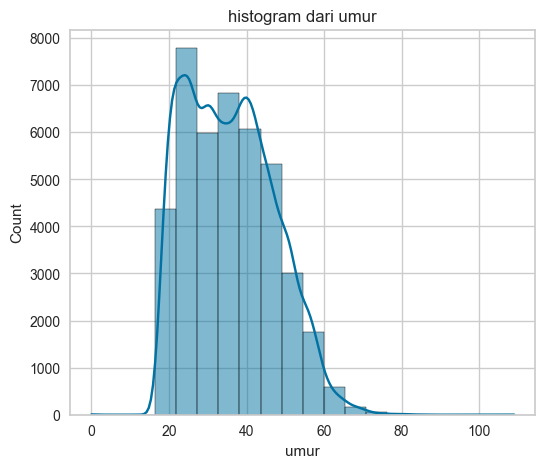

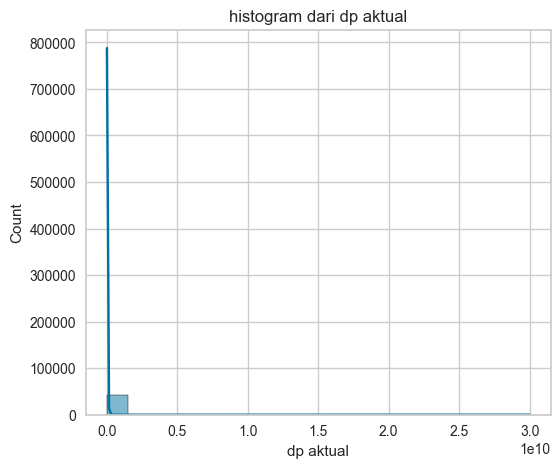

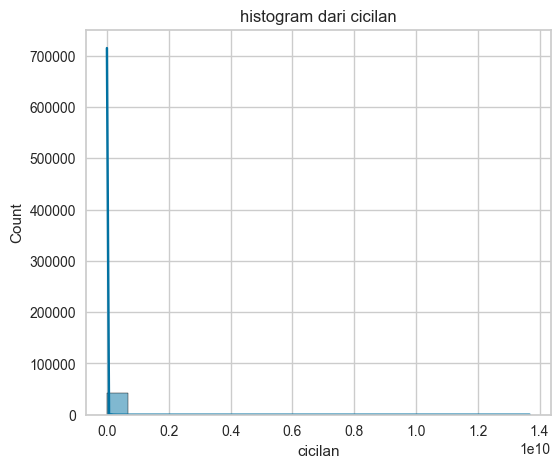

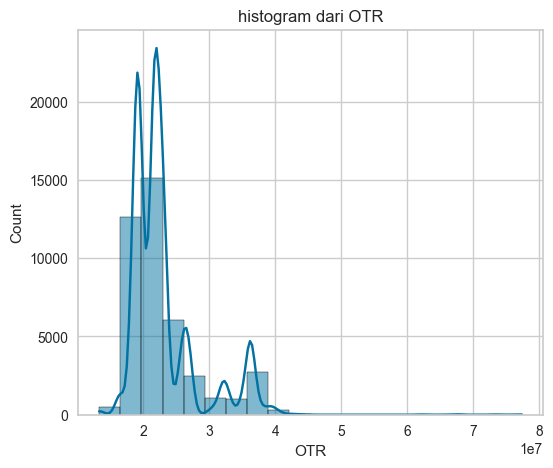

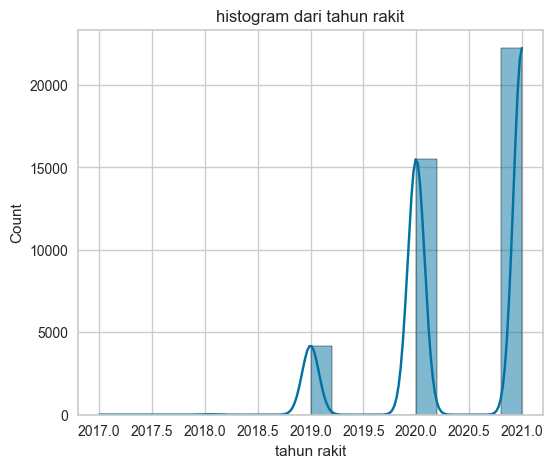

In [20]:
numerical_cols = df.select_dtypes(include=np.number).columns

for col in numerical_cols:
  plt.figure(figsize=(6,5))
  sns.histplot(df[col],kde=True,bins=20)
  plt.title(f'histogram dari {col}')
  plt.show()

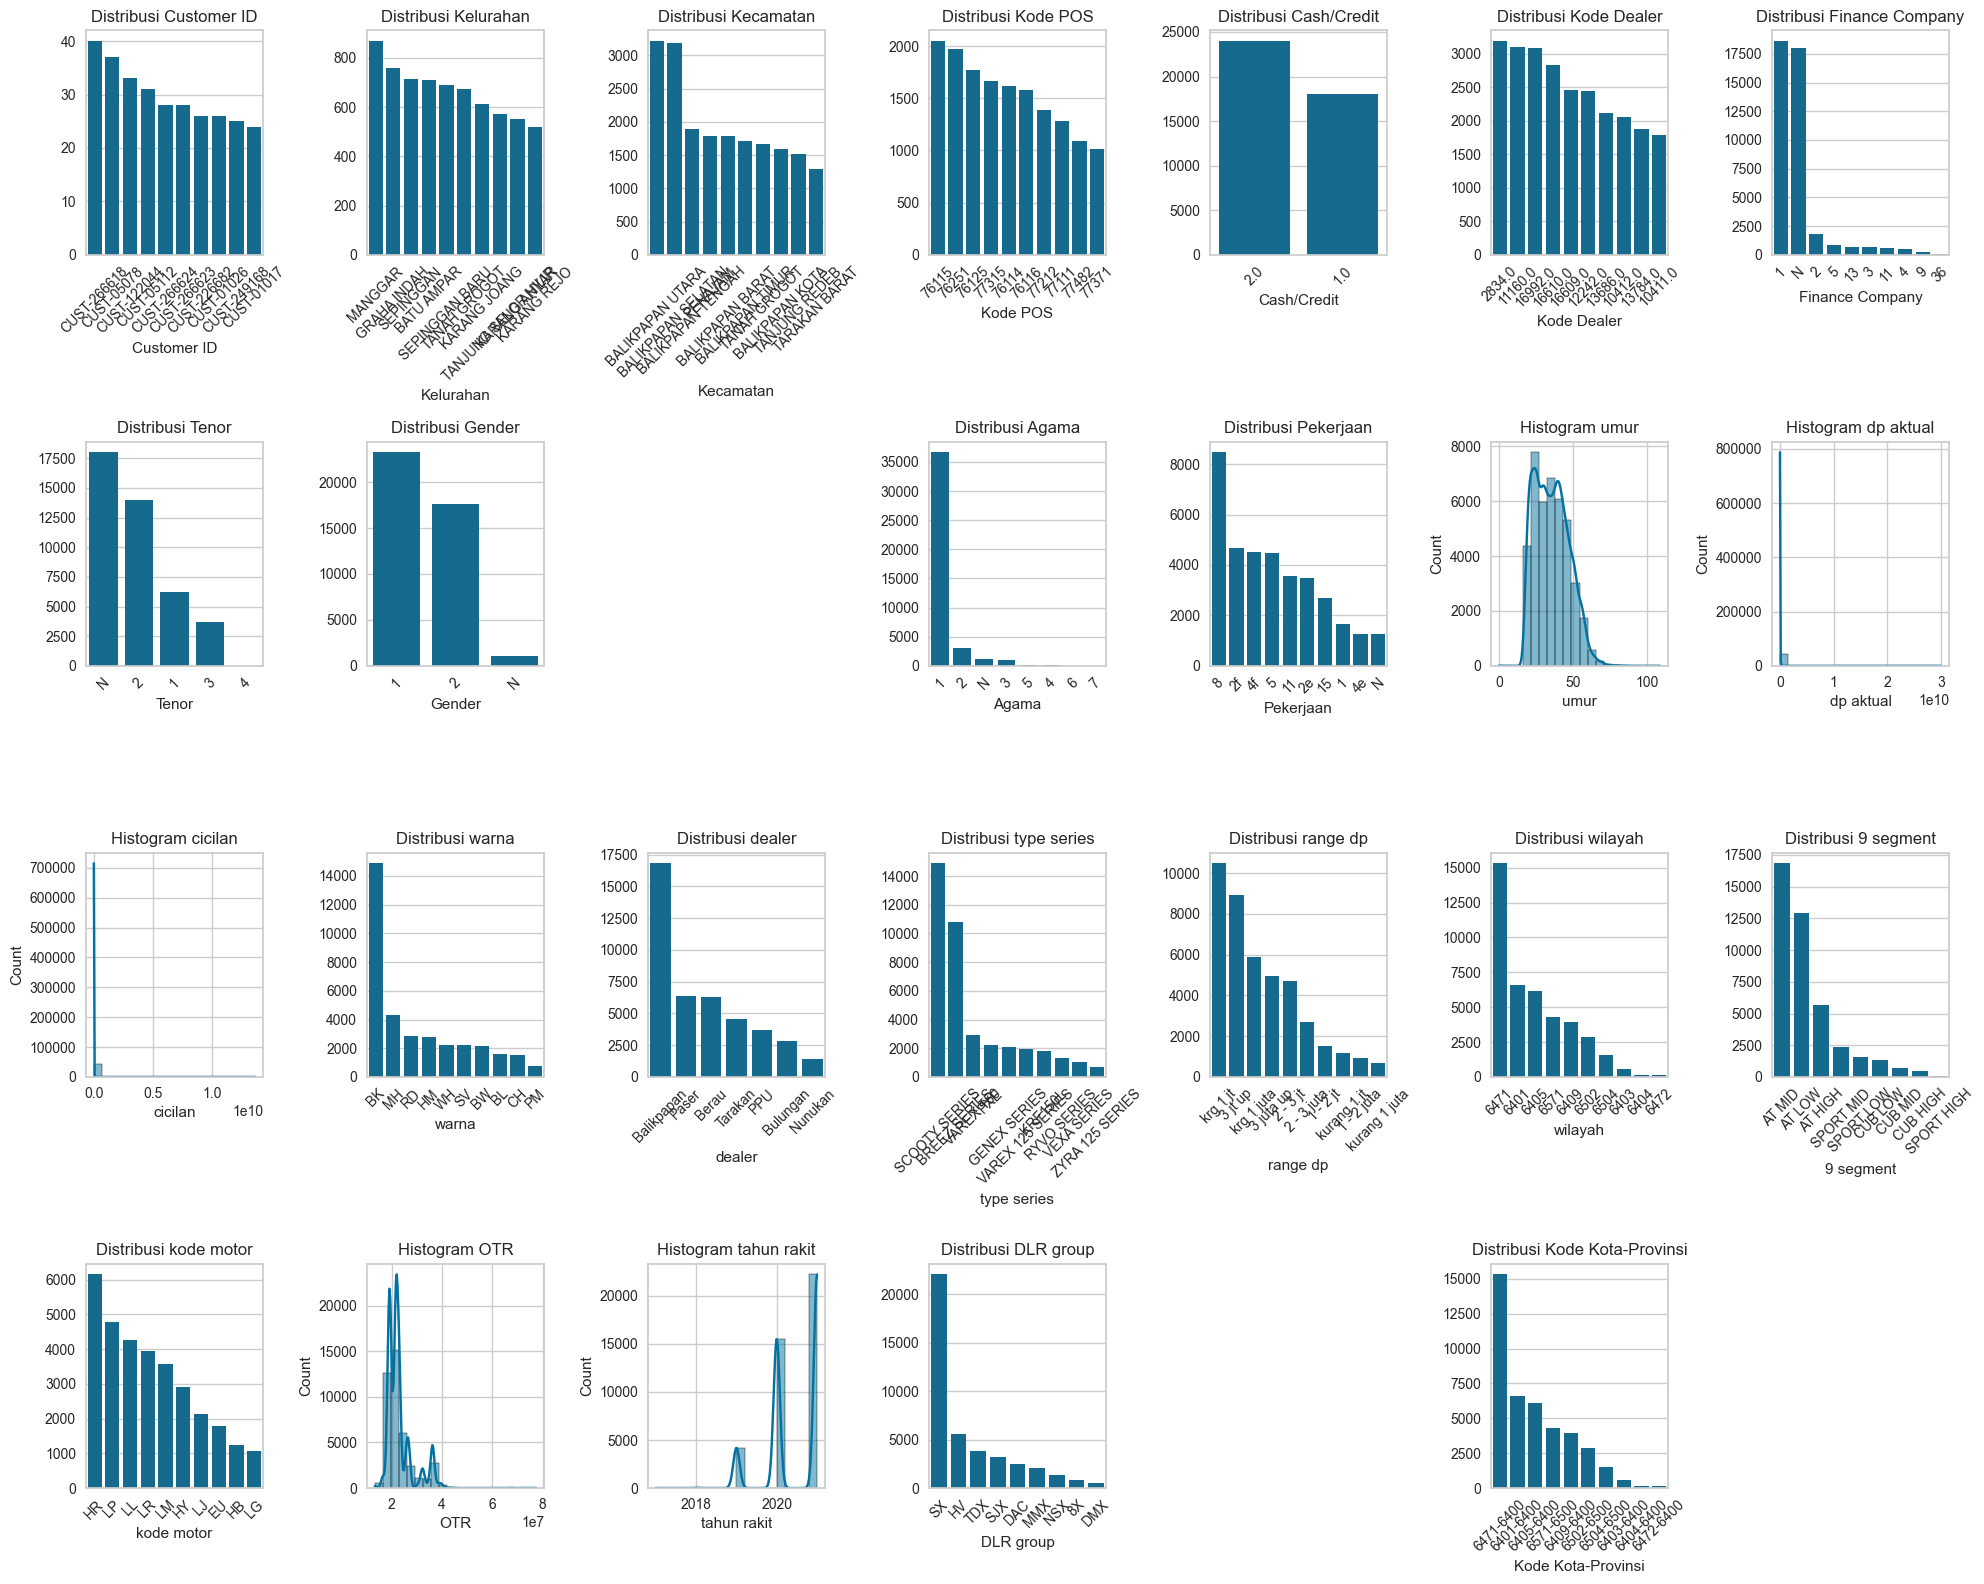

In [21]:
# Visualisasi yang lebih informatif (Opsional Advanced 1)
numerical_cols = df.select_dtypes(include=['int64','float64']).columns
categorical_cols= df.select_dtypes(include=['object','category','string']).columns

all_cols = df.columns
n = len(all_cols)

ncols = 7  # Lebih banyak kolom agar muat di layar
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 4*nrows))  # Lebih rendah per row
axes = axes.flatten()

for i, col in enumerate(all_cols):
    ax = axes[i]
    if col in numerical_cols:
        sns.histplot(df[col], kde=True, bins=20, ax=ax)
        ax.set_title(f"Histogram {col}")
    elif col in categorical_cols:
        vc = df[col].value_counts().nlargest(10)
        sns.barplot(x=vc.index, y=vc.values, ax=ax)
        ax.set_title(f"Distribusi {col}")
        ax.tick_params(axis='x', rotation=45)
    else:
        ax.set_visible(False)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [22]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [23]:
df.columns.unique

<bound method Index.unique of Index(['Customer ID', 'Kelurahan', 'Kecamatan', 'Kode POS', 'Cash/Credit',
       'Kode Dealer', 'Finance Company', 'Tenor', 'Gender', 'Tgl Lahir',
       'Agama', 'Pekerjaan', 'umur', 'dp aktual', 'cicilan', 'warna', 'dealer',
       'type series', 'range dp', 'wilayah', '9 segment', 'kode motor', 'OTR',
       'tahun rakit', 'DLR group', 'tgl mohon', 'Kode Kota-Provinsi'],
      dtype='object')>

fitur yang dipakai: Tenor, tahun rakit (atau usia unit), dp aktual, cicilan, Cash/Credit, Harga OTR, Pekerjaan  (DARFT)

dp aktual anomali 

In [24]:
# # Standardisasi kategori
# df['range dp'] = df['range dp'].str.upper().str.strip().replace({
#     '2 - 3 JT': '2-3JT',
#     '2 - 3 JUTA': '2-3JT',
#     '3 JUTA UP': '>3JT',
#     '3 JT UP': '>3JT',
#     'KURANG 1 JUTA': '<1JT',
#     'KRG 1 JUTA': '<1JT',
#     'KRG 1 JT': '<1JT',
#     '1 - 2 JT': '1-2JT',
#     '1 - 2 JUTA': '1-2JT',
#     'KURANG 1 JT': '<1JT'
# })
# #drop baris yang memiliki nilai range dp yang nan
# df = df.dropna(subset=['range dp'])

# print(f"Range DP unique: {df['range dp'].unique()}")

In [25]:
# #standardisasi kategori lainnya
# df['Agama'] = df['Agama'].astype(str).str.upper().str.strip()
# df['Pekerjaan'] = df['Pekerjaan'].astype(str).str.upper().str.strip()
# df['Gender'] = df['Gender'].astype(str).str.upper().str.strip()
# df['warna'] = df['warna'].str.upper().str.strip()

In [26]:
# df['tgl mohon'] = pd.to_datetime(df['tgl mohon'], errors='coerce', dayfirst=True)
# df['tgl cetak'] = pd.to_datetime(df['tgl cetak'], errors='coerce', dayfirst=True)
# df['Tgl Lahir'] = pd.to_datetime(df['Tgl Lahir'], errors='coerce', dayfirst=True)

# print(f"tgl mohon: {df['tgl mohon'].dtype}")
# print(f"tgl cetak: {df['tgl cetak'].dtype}")
# print(f"Tgl Lahir: {df['Tgl Lahir'].dtype}")
# print(df['tgl mohon'].head())
# print(df['tgl cetak'].head())
# print(df['Tgl Lahir'].head())


In [ ]:

# ============================================================
# FEATURE ENGINEERING, NORMALIZATION & TRANSFORMATION
# ============================================================
# Features identified for transformation:
#
# NUMERICAL (outlier capping + MinMaxScaler):
#   - umur        : min=0 (anomali), max=109 (outlier) → IQR capping
#   - dp aktual   : dp=0 untuk kredit = anomali → handle + IQR capping
#   - cicilan     : highly skewed → IQR capping + scaling
#   - OTR         : highly skewed → IQR capping + scaling
#   - tahun rakit : year value → convert to usia_unit (2026 - tahun rakit)
#
# CATEGORICAL (LabelEncoder):
#   - Tenor       : stored as string → convert to numeric
#   - Cash/Credit : 1=Cash / 2=Credit → binary encode (0/1)
#   - Pekerjaan   : multi-class string → LabelEncoder
#   - Gender      : multi-class string → LabelEncoder
#   - Agama       : multi-class string → LabelEncoder
#   - 9 segment   : segment category → LabelEncoder
#
# DATE (feature extraction):
#   - tgl mohon   : application date → recency_bulan (months from 2026-01-01)
#   - Tgl Lahir   : already captured in umur column
# ============================================================

# from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# print("Shape sebelum transformasi:", df.shape)
# df_clean = df.copy()

# # ----------------------------------------------------------
# # 1. FEATURE ENGINEERING: Usia Unit (dari tahun rakit)
# # ----------------------------------------------------------
# TAHUN_INI = 2026
# df_clean['tahun rakit'] = pd.to_numeric(df_clean['tahun rakit'], errors='coerce')
# df_clean['usia_unit'] = TAHUN_INI - df_clean['tahun rakit']
# # Usia unit negatif atau > 30 tahun → anomali
# df_clean.loc[(df_clean['usia_unit'] < 0) | (df_clean['usia_unit'] > 30), 'usia_unit'] = np.nan
# print(f"✓ usia_unit dari tahun rakit. Range: {df_clean['usia_unit'].min():.0f} - {df_clean['usia_unit'].max():.0f} tahun")

# # ----------------------------------------------------------
# # 2. FEATURE ENGINEERING: Recency tgl mohon (bulan)
# # ----------------------------------------------------------
# ref_date = pd.Timestamp('2026-01-01')
# df_clean['recency_bulan'] = ((ref_date - df_clean['tgl mohon']) / pd.Timedelta(days=30)).round(1)
# df_clean.loc[df_clean['recency_bulan'] < 0, 'recency_bulan'] = np.nan
# print(f"✓ recency_bulan dari tgl mohon. Range: {df_clean['recency_bulan'].min():.0f} - {df_clean['recency_bulan'].max():.0f} bulan")

# # ----------------------------------------------------------
# # 3. TENOR: String → Numerik
# # ----------------------------------------------------------
# df_clean['Tenor'] = pd.to_numeric(df_clean['Tenor'], errors='coerce')
# print(f"✓ Tenor → numerik. Unique: {sorted(df_clean['Tenor'].dropna().astype(int).unique())[:10]}")

# # ----------------------------------------------------------
# # 4. ANOMALI: dp aktual = 0 untuk transaksi Kredit
# #    Cash (1) → dp bisa 0; Kredit (2) → dp = 0 tidak valid
# # ----------------------------------------------------------
# mask_credit_dp_zero = (df_clean['Cash/Credit'] == 2) & (df_clean['dp aktual'] == 0)
# df_clean.loc[mask_credit_dp_zero, 'dp aktual'] = np.nan
# print(f"\n✓ dp aktual=0 pada kredit → NaN ({mask_credit_dp_zero.sum():,} baris)")

# # ANOMALI: umur = 0
# mask_umur_zero = df_clean['umur'] == 0
# df_clean.loc[mask_umur_zero, 'umur'] = np.nan
# print(f"✓ umur=0 → NaN ({mask_umur_zero.sum():,} baris)")

# # ----------------------------------------------------------
# # 5. IQR CAPPING — outlier numerik (1% - 99%)
# # ----------------------------------------------------------
# def iqr_cap(series, lower_q=0.01, upper_q=0.99):
#     lo = series.quantile(lower_q)
#     hi = series.quantile(upper_q)
#     return series.clip(lower=lo, upper=hi)

# cols_to_cap = ['dp aktual', 'cicilan', 'OTR', 'umur', 'usia_unit', 'Tenor']
# print("\n[IQR Capping 1%-99%]")
# for col in cols_to_cap:
#     before = (df_clean[col].min(), df_clean[col].max())
#     df_clean[col] = iqr_cap(df_clean[col])
#     after  = (df_clean[col].min(), df_clean[col].max())
#     print(f"  {col:<12}: [{before[0]:,.0f}, {before[1]:,.0f}] → [{after[0]:,.0f}, {after[1]:,.0f}]")

# # ----------------------------------------------------------
# # 6. ENCODING KATEGORIKAL
# # ----------------------------------------------------------
# print("\n[Label Encoding]")

# # Cash/Credit: 1 (Cash) → 0, 2 (Credit) → 1
# df_clean['Cash_Credit_enc'] = (df_clean['Cash/Credit'] == 2).astype(int)
# print(f"  Cash/Credit  : {dict(zip([1,2], [0,1]))} → dist: {df_clean['Cash_Credit_enc'].value_counts().to_dict()}")

# # Pekerjaan
# le_pekerjaan = LabelEncoder()
# df_clean['Pekerjaan_enc'] = le_pekerjaan.fit_transform(df_clean['Pekerjaan'].astype(str))
# print(f"  Pekerjaan    : {len(le_pekerjaan.classes_)} kelas → {list(le_pekerjaan.classes_)[:6]}...")

# # Gender
# le_gender = LabelEncoder()
# df_clean['Gender_enc'] = le_gender.fit_transform(df_clean['Gender'].astype(str))
# print(f"  Gender       : {dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_)))}")

# # Agama
# le_agama = LabelEncoder()
# df_clean['Agama_enc'] = le_agama.fit_transform(df_clean['Agama'].astype(str))
# print(f"  Agama        : {len(le_agama.classes_)} kelas")

# # 9 segment
# le_segment = LabelEncoder()
# df_clean['segment_enc'] = le_segment.fit_transform(df_clean['9 segment'].astype(str))
# print(f"  9 segment    : {len(le_segment.classes_)} kelas → {list(le_segment.classes_)}")

# # ----------------------------------------------------------
# # 7. PILIH FITUR DAN DROP NaN
# # ----------------------------------------------------------
# features_cluster = [
#     'Tenor',           # Jangka waktu cicilan
#     'usia_unit',       # Usia kendaraan
#     'dp aktual',       # Down payment
#     'cicilan',         # Besaran cicilan bulanan
#     'Cash_Credit_enc', # Cash=0 / Kredit=1
#     'OTR',             # Harga on the road
#     'umur',            # Usia nasabah
#     'Pekerjaan_enc',   # Jenis pekerjaan
#     'recency_bulan',   # Recency pembelian
# ]

# df_features = df_clean[features_cluster].dropna().copy()
# print(f"\n✓ Dataset fitur siap: {df_features.shape[0]:,} baris × {df_features.shape[1]} fitur")
# print(f"  (drop {len(df_clean) - len(df_features):,} baris karena masih ada NaN)")

# # ----------------------------------------------------------
# # 8. NORMALISASI — MinMaxScaler → [0, 1]
# # ----------------------------------------------------------
# scaler = MinMaxScaler()
# df_scaled = pd.DataFrame(
#     scaler.fit_transform(df_features),
#     columns=df_features.columns,
#     index=df_features.index
# )

# print("\n✓ Normalisasi MinMaxScaler selesai. Statistik df_scaled:")
# print(df_scaled.describe().round(3).to_string())


Shape sebelum transformasi: (41580, 27)
✓ usia_unit dari tahun rakit. Range: 5 - 9 tahun
✓ recency_bulan dari tgl mohon. Range: 49 - 73 bulan
✓ Tenor → numerik. Unique: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

✓ dp aktual=0 pada kredit → NaN (0 baris)
✓ umur=0 → NaN (2 baris)

[IQR Capping 1%-99%]
  dp aktual   : [0, 30,000,000,000] → [0, 148,000,000]
  cicilan     : [0, 13,680,000,000] → [0, 28,000,000]
  OTR         : [13,310,000, 77,380,000] → [16,485,300, 38,710,000]
  umur        : [17, 109] → [18, 63]
  usia_unit   : [5, 9] → [5, 7]
  Tenor       : [1, 4] → [1, 3]

[Label Encoding]
  Cash/Credit  : {1: 0, 2: 1} → dist: {0: 41580}
  Pekerjaan    : 26 kelas → ['1', '11', '12', '13', '14', '15']...
  Gender       : {'1': np.int64(0), '2': np.int64(1), 'N': np.int64(2)}
  Agama        : 8 kelas
  9 segment    : 9 kelas → ['AT HIGH', 'AT LOW', 'AT MID', 'CUB HIGH', 'CUB LOW', 'CUB MID', 'SPORT HIGH', 'SPORT LOW', 'SPORT MID']

✓ Dataset fitur siap: 23,953 baris × 9 fitur


Labeling

In [ ]:

# ==============================================================================
# DOMAIN-BASED PREPROCESSING PIPELINE FOR K-MEANS CLUSTERING
# SPARC 2026 — Motorcycle Loan Dataset
# ==============================================================================
# Strategy: Replace blind IQR capping with domain-specific rules per feature.
# Each transformer targets one business concern, then feeds into MinMaxScaler.
# ==============================================================================

import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

# ------------------------------------------------------------------------------
# STEP 0: BUILD WORKING COPY WITH PREREQUISITE FEATURES
# (tahun rakit → usia_unit, tgl mohon → recency_bulan, categorical encoding)
# ------------------------------------------------------------------------------

df_work = df.copy()

# --- usia_unit (Vehicle Age) ---
TAHUN_INI = 2026
df_work['tahun rakit'] = pd.to_numeric(df_work['tahun rakit'], errors='coerce')
df_work['usia_unit'] = TAHUN_INI - df_work['tahun rakit']
# Out-of-range years (future or >30 years old) → NaN before pipeline
df_work.loc[(df_work['usia_unit'] < 0) | (df_work['usia_unit'] > 30), 'usia_unit'] = np.nan

# --- recency_bulan (Application Recency) ---
ref_date = pd.Timestamp('2026-01-01')
df_work['recency_bulan'] = (
    (ref_date - df_work['tgl mohon']) / pd.Timedelta(days=30)
).round(1)
df_work.loc[df_work['recency_bulan'] < 0, 'recency_bulan'] = np.nan

# --- Tenor: string → numeric ---
df_work['Tenor'] = pd.to_numeric(df_work['Tenor'], errors='coerce')

# --- Cash/Credit: binary encode (Cash=0 / Credit=1) ---
df_work['Cash_Credit_enc'] = (df_work['Cash/Credit'] == 2).astype(float)

# --- Categorical encodings ---
for col_name, enc_name in [('Pekerjaan', 'Pekerjaan_enc'),
                            ('Gender',    'Gender_enc'),
                            ('Agama',     'Agama_enc'),
                            ('9 segment', 'segment_enc')]:
    le = LabelEncoder()
    df_work[enc_name] = le.fit_transform(df_work[col_name].astype(str)).astype(float)

# Features entering the pipeline
FEATURE_COLS = [
    'umur',            # Customer age
    'dp aktual',       # Down payment
    'cicilan',         # Monthly installment
    'OTR',             # On-the-road vehicle price
    'usia_unit',       # Vehicle age (engineered)
    'Tenor',           # Loan duration (ordinal: 1/2/3)
    'Cash_Credit_enc', # Cash = 0 / Credit = 1
    'Pekerjaan_enc',   # Job type
    'recency_bulan',   # Months since application
]

print(f"Working dataframe shape before pipeline: {df_work.shape}")


# ==============================================================================
# CUSTOM TRANSFORMERS
# ==============================================================================

# ------------------------------------------------------------------------------
# Transformer 1: UmurDomainCapper
# Business Rule: Legal credit age in Indonesia is min 17, max 65 (productive).
#   - umur == 0  → absolute data entry error for a loan applicant → NaN
#   - umur < 17  → legally ineligible for credit → NaN
#   - umur > 65  → outside productive/insurable age → hard cap at 65
# No log transform: age is roughly normal / uniform, no heavy skew.
# ------------------------------------------------------------------------------
class UmurDomainCapper(BaseEstimator, TransformerMixin):
    """Hard-cap customer age to the legal credit age range [17, 65]."""
    
    AGE_MIN = 17   # Legal minimum age for credit in Indonesia
    AGE_MAX = 65   # Maximum productive / insurable age
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        # Ages below legal minimum → NaN (not just a statistical outlier)
        X.loc[X['umur'] < self.AGE_MIN, 'umur'] = np.nan
        # Ages above productive max → cap at 65 (legitimate elderly borrowers
        # exist, but values like 109 are data entry errors)
        X.loc[X['umur'] > self.AGE_MAX, 'umur'] = self.AGE_MAX
        return X


# ------------------------------------------------------------------------------
# Transformer 2: CurrencyAnomalyCleaner
# Business Rules for dp aktual & cicilan:
#   Rule A — Logical Anomaly: Credit transactions (Cash/Credit==2) where
#             dp aktual==0 or cicilan==0 violate financial product definition.
#             These rows carry no clustering signal → set to NaN.
#   Rule B — Typo Cap: Down payment and installment CANNOT physically exceed
#             the vehicle's OTR price. E.g., dp=30B IDR with OTR=40M IDR is
#             a data entry error (likely extra zeros). Cap at OTR per row.
#   Rule C — Log1p Transform: Currency features are heavily right-skewed.
#             log1p compresses the range (handles zeros safely) and brings
#             premium and budget segments closer for distance-based clustering.
# ------------------------------------------------------------------------------
class CurrencyAnomalyCleaner(BaseEstimator, TransformerMixin):
    """
    Clean dp aktual & cicilan with domain rules, then apply log1p.
    Requires columns: 'dp aktual', 'cicilan', 'Cash_Credit_enc', 'OTR'.
    """
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        
        # --- Rule A: Credit with zero dp or cicilan → NaN ---
        is_credit = X['Cash_Credit_enc'] == 1
        X.loc[is_credit & (X['dp aktual'] == 0), 'dp aktual'] = np.nan
        X.loc[is_credit & (X['cicilan']   == 0), 'cicilan']   = np.nan
        
        # --- Rule B: Cap dp aktual and cicilan to max = OTR of that row ---
        # dp aktual > OTR means the customer "pays more than the bike costs" — typo
        X.loc[X['dp aktual'] > X['OTR'], 'dp aktual'] = X['OTR']
        # cicilan (monthly) > OTR is physically impossible for any tenor ≥ 1
        X.loc[X['cicilan']   > X['OTR'], 'cicilan']   = X['OTR']
        
        # --- Rule C: Log1p transformation for heavy right-skew ---
        # log1p(0) = 0, safe for zero down payments (cash transactions)
        X['dp aktual'] = np.log1p(X['dp aktual'])
        X['cicilan']   = np.log1p(X['cicilan'])
        
        return X


# ------------------------------------------------------------------------------
# Transformer 3: OTRLogTransformer
# Business Rule: Max OTR is 77.38M IDR which is valid (premium big-bike).
#   - NO capping: capping would collapse premium segment into mid-range,
#     destroying the very cluster distinction we want to find.
#   - Apply log1p only to reduce rightward skew from budget vs premium spread.
# ------------------------------------------------------------------------------
class OTRLogTransformer(BaseEstimator, TransformerMixin):
    """Log1p-transform OTR (vehicle price). No capping — premium is valid."""
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        X['OTR'] = np.log1p(X['OTR'])
        return X


# ------------------------------------------------------------------------------
# Transformer 4: PassThroughValidator
# Business Rule for usia_unit & Tenor:
#   - usia_unit: manufacturing years 2017-2021 → all valid (range 5-9 years).
#     No capping needed; NaN already handled above.
#   - Tenor: ordinal categories (1=<1yr, 2=1-2yr, 3=>2yr). These are clean
#     discrete values; applying IQR cap would corrupt the ordinal meaning.
# This transformer is a no-op (identity) but documents the decision explicitly.
# ------------------------------------------------------------------------------
class PassThroughValidator(BaseEstimator, TransformerMixin):
    """
    Validates that usia_unit and Tenor are in expected ranges.
    Flags unexpected values as NaN; does NOT cap or transform.
    """
    USIA_UNIT_MAX = 30   # motorcycles older than 30y are invalid in dataset
    TENOR_VALID   = {1, 2, 3, 4}  # allowed ordinal values
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        # usia_unit: negative or unreasonably old → already handled, recheck
        X.loc[(X['usia_unit'] < 0) | (X['usia_unit'] > self.USIA_UNIT_MAX), 'usia_unit'] = np.nan
        # Tenor: any value not in valid set → NaN
        X.loc[~X['Tenor'].isin(self.TENOR_VALID), 'Tenor'] = np.nan
        return X


# ------------------------------------------------------------------------------
# Transformer 5: FeatureSelector + NaN dropper
# Selects only the clustering features and drops rows with any remaining NaN.
# Must be the final step before MinMaxScaler.
# ------------------------------------------------------------------------------
class FeatureSelectorDropNA(BaseEstimator, TransformerMixin):
    """Select clustering features and drop any rows that still contain NaN."""
    
    def __init__(self, feature_cols):
        self.feature_cols = feature_cols
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X_sel = X[self.feature_cols].copy()
        before = len(X_sel)
        X_sel = X_sel.dropna()
        dropped = before - len(X_sel)
        print(f"  [FeatureSelector] Kept {len(X_sel):,} rows | Dropped {dropped:,} NaN rows")
        return X_sel


# ==============================================================================
# PIPELINE ASSEMBLY
# ==============================================================================
# Note: sklearn Pipeline requires all transformers to return numpy arrays for
# the final MinMaxScaler step. We keep DataFrames through custom steps and
# convert after FeatureSelectorDropNA.

class DataFrameMinMaxScaler(BaseEstimator, TransformerMixin):
    """MinMaxScaler wrapper that accepts and returns a DataFrame."""
    
    def __init__(self):
        self.scaler = MinMaxScaler()
        self.columns_ = None
        self.index_    = None
    
    def fit(self, X, y=None):
        self.columns_ = X.columns
        self.scaler.fit(X)
        return self
    
    def transform(self, X):
        self.index_ = X.index
        arr = self.scaler.transform(X)
        return pd.DataFrame(arr, columns=self.columns_, index=X.index)


# Build the pipeline
CLUSTER_FEATURES = [
    'umur', 'dp aktual', 'cicilan', 'OTR',
    'usia_unit', 'Tenor', 'Cash_Credit_enc',
    'Pekerjaan_enc', 'recency_bulan',
]

domain_pipeline = Pipeline(steps=[
    ('umur_cap',       UmurDomainCapper()),        # Rule: hard cap age [17, 65]
    ('currency_clean', CurrencyAnomalyCleaner()),   # Rule: anomaly + OTR cap + log1p
    ('otr_log',        OTRLogTransformer()),        # Rule: log1p only, no cap
    ('passthrough',    PassThroughValidator()),      # Rule: validate, do NOT cap
    ('select_dropna',  FeatureSelectorDropNA(CLUSTER_FEATURES)),  # select & clean
    ('scaler',         DataFrameMinMaxScaler()),    # Normalize to [0, 1]
])

# ==============================================================================
# EXECUTE PIPELINE
# ==============================================================================
print("=" * 65)
print("DOMAIN-BASED PREPROCESSING PIPELINE — SPARC 2026")
print("=" * 65)
print(f"Input shape : {df_work.shape}")
print()

df_scaled_domain = domain_pipeline.fit_transform(df_work)

print()
print(f"Output shape: {df_scaled_domain.shape}")
print()
print("Statistics of scaled features (all values should be in [0, 1]):")
print(df_scaled_domain.describe().round(3).to_string())


Working dataframe shape before pipeline: (41580, 34)
DOMAIN-BASED PREPROCESSING PIPELINE — SPARC 2026
Input shape : (41580, 34)

  [FeatureSelector] Kept 23,953 rows | Dropped 17,627 NaN rows

Output shape: (23953, 9)

Statistics of scaled features (all values should be in [0, 1]):
            umur  dp aktual    cicilan        OTR  usia_unit      Tenor  Cash_Credit_enc  Pekerjaan_enc  recency_bulan
count  23953.000  23953.000  23953.000  23953.000  23953.000  23953.000          23953.0      23953.000      23953.000
mean       0.379      0.918      0.904      0.300      0.190      0.299              0.0          0.591          0.477
std        0.224      0.026      0.054      0.115      0.225      0.212              0.0          0.313          0.309
min        0.000      0.000      0.000      0.000      0.000      0.000              0.0          0.000          0.000
25%        0.188      0.912      0.897      0.213      0.000      0.000              0.0          0.400          0.199
50%